In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
%matplotlib inline
sns.set()

In [2]:
data = pd.read_csv(r"D:\data analysis\Projects\Smart Customer Segmentation & Anomaly Detection\data_model.csv")

In [4]:
X = data.values

In [23]:
inertia = []
for n in range(2,11):
    kmeans = KMeans(n_clusters=n, init="k-means++", random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)


Text(0, 0.5, 'Inertia')

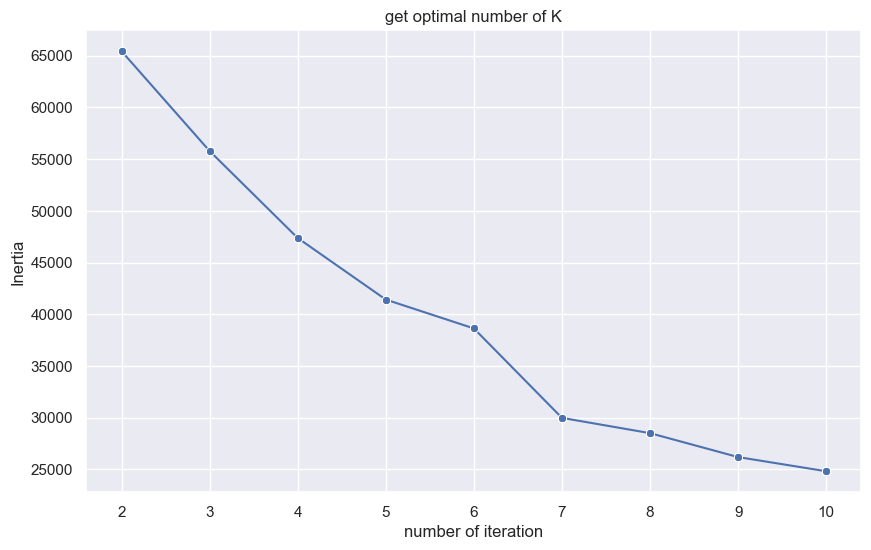

In [24]:
plt.figure(figsize=(10,6))
sns.lineplot(x = range(2,11), y = inertia, marker='8')
plt.title("get optimal number of K")
plt.xlabel("number of iteration")
plt.ylabel("Inertia")

In [25]:
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(
        X,
        labels
    )
    
    silhouette_scores.append(score)

Text(0, 0.5, 'silhouette_scores')

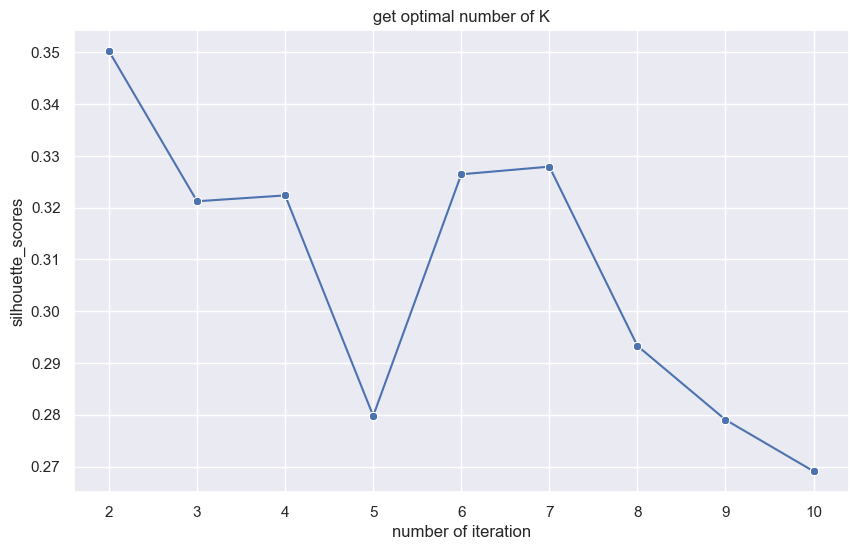

In [26]:
plt.figure(figsize=(10,6))
sns.lineplot(x = range(2,11), y = silhouette_scores, marker='8')
plt.title("get optimal number of K")
plt.xlabel("number of iteration")
plt.ylabel("silhouette_scores")

In [27]:
results = pd.DataFrame({
    "K": list(range(2,11)),
    "Inertia": inertia,
    "Silhouette_Score": silhouette_scores
})

print(results)

    K       Inertia  Silhouette_Score
0   2  65437.818698          0.350223
1   3  55780.861258          0.321246
2   4  47370.630681          0.322373
3   5  41417.609769          0.279789
4   6  38626.961085          0.326454
5   7  29975.784451          0.327933
6   8  28497.178447          0.293312
7   9  26183.042671          0.279038
8  10  24811.440575          0.269093


In [29]:
X

array([[-1.21295498, -0.87928835, -0.09802549, ..., -0.83048728,
        -0.01461281, -0.62927738],
       [ 0.97857809,  0.21956808, -1.69894416, ...,  1.14951245,
        -0.01489933,  0.9739614 ],
       [ 0.85250162, -0.10964163,  0.6320097 , ..., -0.09153424,
        -0.01498027, -0.62927738],
       ...,
       [-1.48623424, -0.92545378,  0.04599299, ..., -1.42446493,
        -0.01472738,  1.17436805],
       [-1.75068815, -0.91617839, -1.69894416, ..., -1.70716324,
        -0.01469353,  1.17436805],
       [-0.10716813, -0.1679257 ,  0.7532683 , ..., -1.58810026,
        -0.01498653, -0.62927738]], shape=(8950, 11))

In [32]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

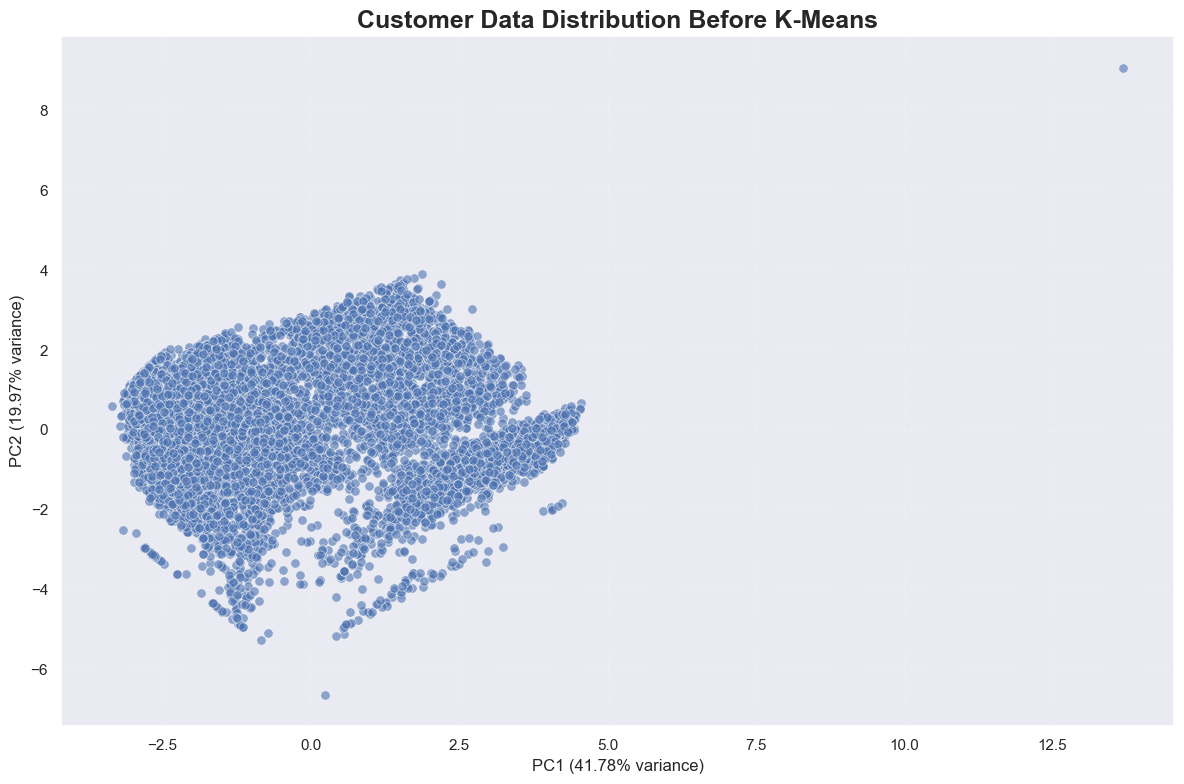

In [33]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    s=45,
    alpha=0.6
)

plt.title(
    "Customer Data Distribution Before K-Means",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.grid(
    alpha=0.2,
    linestyle="--"
)

plt.tight_layout()

plt.show()

In [35]:
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)
cluster = kmeans.fit_predict(X)
cluster

array([1, 3, 4, ..., 2, 1, 0], shape=(8950,), dtype=int32)

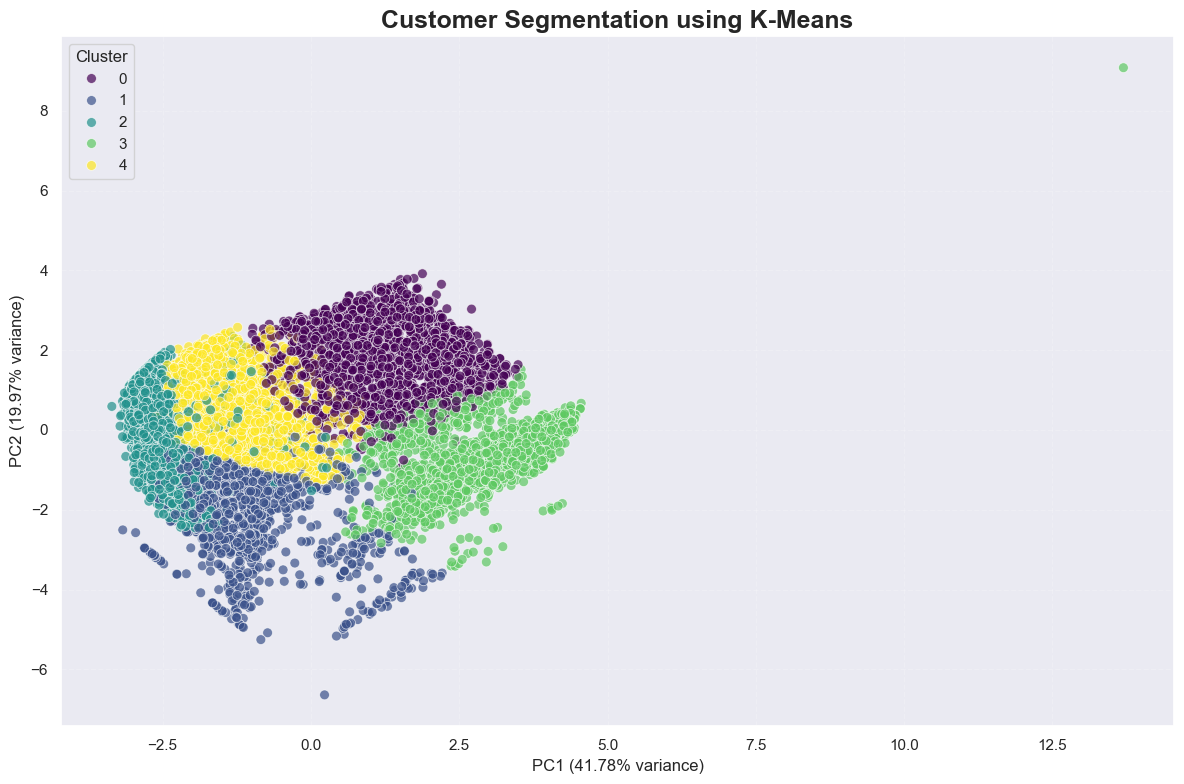

In [42]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster
})


plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    s=50,
    alpha=0.7
)

plt.title(
    "Customer Segmentation using K-Means",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.2,
    linestyle="--"
)

plt.tight_layout()

plt.show()

In [44]:
data = pd.read_csv(r"D:\data analysis\Projects\Smart Customer Segmentation & Anomaly Detection\data_cleaned.csv")

In [45]:
data["cluster"] = cluster

### DBSCAN

In [48]:
outlier = []
for eps in np.linspace(0.001,3,50):
    dbscan = DBSCAN(eps = eps, min_samples= 2 * X.shape[1])
    dbscan.fit(X)
    per_out = 100 * np.sum(dbscan.labels_ == -1 )/ len(dbscan.labels_)
    outlier.append(per_out)


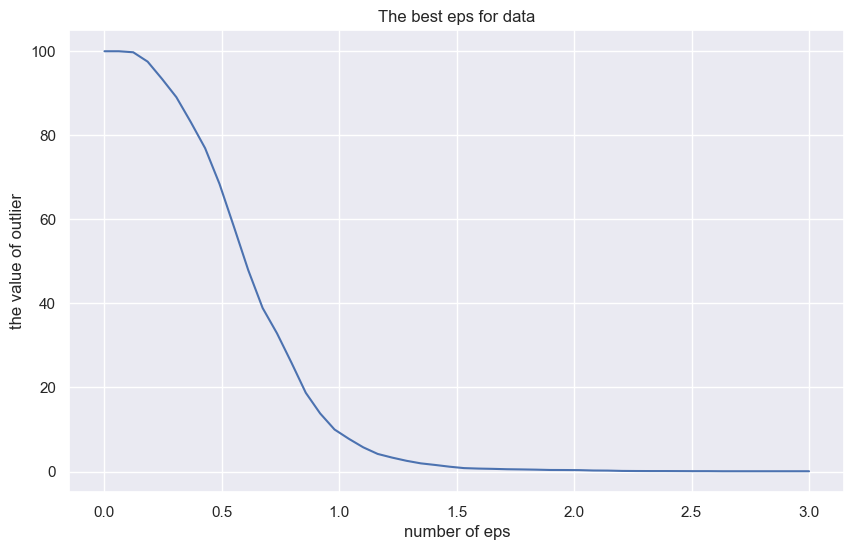

In [50]:
plt.figure(figsize=(10,6))
sns.lineplot(x = np.linspace(0.001,3,50), y = outlier)
plt.title("The best eps for data")
plt.xlabel("number of eps")
plt.ylabel("the value of outlier")
plt.show()

In [65]:
dbscan = DBSCAN(eps = 1.5, min_samples= 5)
label = dbscan.fit_predict(X)

In [ ]:
label

<function ndarray.all(axis=None, out=None, keepdims=False, *, where=True)>

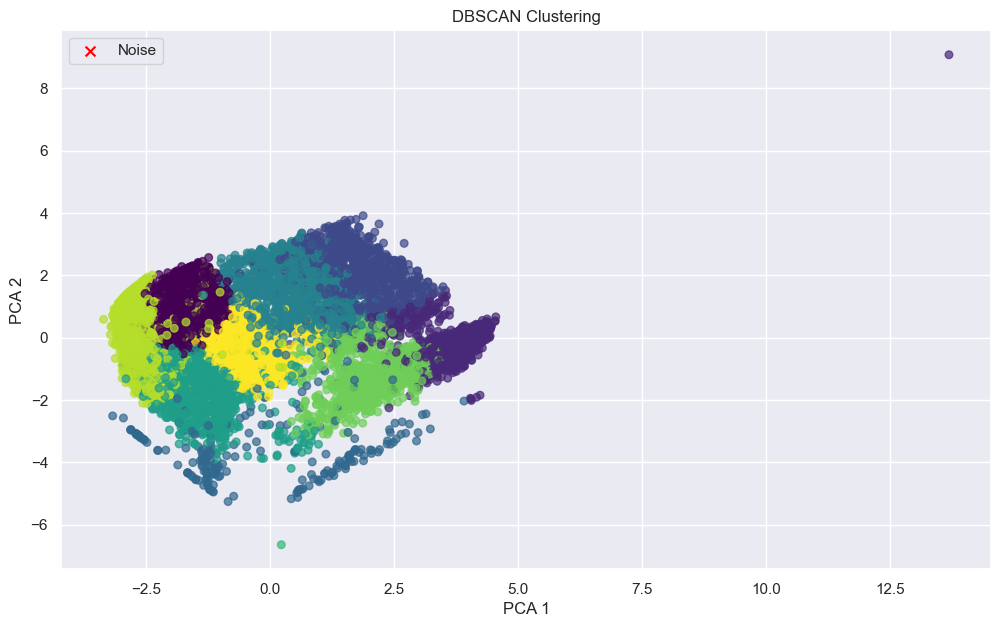

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA على نفس البيانات اللي استخدمتها في DBSCAN
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)


# Plot
plt.figure(figsize=(12, 7))

# Noise = -1
noise = labels == -1

# Clusters
plt.scatter(
    X_pca[~noise, 0],
    X_pca[~noise, 1],
    c=labels[~noise],
    cmap='viridis',
    s=30,
    alpha=0.7
)

# Noise
plt.scatter(
    X_pca[noise, 0],
    X_pca[noise, 1],
    c='red',
    marker='x',
    s=50,
    label='Noise'
)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.legend()
plt.show()